## Imports

In [1]:
import pickle
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from lime import lime_tabular
import lightning as L
import torch
import torch.nn as nn
import torchmetrics
from sklearn.metrics import roc_curve, auc, balanced_accuracy_score, jaccard_score
from torchmetrics import Precision, Recall, F1Score
from lightning.pytorch.callbacks import Callback
from torchmetrics.functional import recall
from pnpl.datasets import LibriBrainSpeech
from torch.utils.data import DataLoader

/opt/miniconda3/envs/pytorch_env/lib/python3.13/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [ ]:
import numpy as np
import copy
from sklearn.metrics import pairwise_distances
from sklearn.linear_model import LinearRegression
import torch

def calculate_cosine_distances(random_perturbations, num_slices):
    """
    Calculates the cosine distances between each perturbation vector and the original signal representation.

    Parameters:
    - random_perturbations (np.ndarray): An array of perturbation vectors.
    - num_slices (int): The total number of segments the ECG signal is divided into, matching the dimension of the perturbations.

    Returns:
    - np.ndarray: An array of cosine distances for each perturbation from the original signal representation.
    """
    # Represent the original ECG signal as a perturbation where all segments are enabled (i.e., a vector of ones)
    original_ecg_rep = np.ones((1, num_slices))

    # Calculate cosine distances
    cosine_distances = pairwise_distances(random_perturbations, original_ecg_rep, metric='cosine').ravel()

    return cosine_distances


def analyze_prediction(probability_vector, class_labels):
    """
    Analyzes the probability vector from a model prediction, returning the top predicted classes
    and the most likely predicted class.
    
    Parameters:
        probability_vector (np.ndarray): The probability vector for a given instance, as predicted by the model.
        class_labels (list): A list of class labels, adjusted to be zero-based.
    
    Returns:
        tuple: A tuple containing a list of the top predicted classes and the most likely predicted class.
    """
    # Sort the classes based on the probability vector and select the top N classes
    top_pred_classes = probability_vector[0].argsort()[-len(class_labels):][::-1]
    
    # Use np.argmax to find the index of the maximum value in the probability vector
    predicted_class_index = np.argmax(probability_vector, axis=1)
    
    # Map the predicted index to its corresponding class label
    predicted_classes = [class_labels[i] for i in predicted_class_index]
    
    # Since we're predicting for one instance, access the first element for the predicted class
    predicted_class = predicted_classes[0]
    
    return top_pred_classes, predicted_class


def segment_ecg_signal(instance_ecg, num_slices=40):
    """
    Segments an ECG signal into a fixed number of slices.

    Parameters:
        instance_ecg (np.ndarray): The ECG signal instance to segment.
        num_slices (int): The number of slices to divide the signal into.

    Returns:
        int: The width of each slice in the segmented ECG signal.
    """
    total_length = instance_ecg.shape[-1]
    slice_width = total_length // num_slices
    return slice_width

def perturb_total_mean(signal, start_idx, end_idx):
    """
    Perturbs a segment of the signal by replacing it with the overall mean of the signal.
    
    Parameters:
        signal (np.ndarray): The original signal to perturb.
        start_idx (int): The starting index of the segment to perturb.
        end_idx (int): The ending index of the segment to perturb.
        
    Returns:
        np.ndarray: The signal with the specified segment perturbed by the total mean.
    """
    modified_signal = signal.copy()
    modified_signal[start_idx:end_idx] = modified_signal.mean()
    return modified_signal

def perturb_mean(signal, start_idx, end_idx):
    """
    Directly modifies a segment of the signal by replacing it with the mean of that segment.
    
    Parameters:
        signal (np.ndarray): The signal to perturb, modified in place.
        start_idx (int): The starting index of the segment to perturb.
        end_idx (int): The ending index of the segment to perturb.
    """
    mean_value = np.mean(signal[start_idx:end_idx])
    signal[start_idx:end_idx] = mean_value

def perturb_noise(signal, start_idx, end_idx):
    """
    Perturbs a segment of the signal by replacing it with random noise within the signal's range.
    
    Parameters:
        signal (np.ndarray): The original signal to perturb.
        start_idx (int): The starting index of the segment to perturb.
        end_idx (int): The ending index of the segment to perturb.
        
    Returns:
        np.ndarray: The signal with the specified segment perturbed by random noise.
    """
    modified_signal = signal.copy()
    modified_signal[start_idx:end_idx] = np.random.uniform(modified_signal.min(), modified_signal.max(), end_idx - start_idx)
    return modified_signal

def generate_random_perturbations(num_perturbations, num_slices):
    """
    Generates random perturbations for ECG signal segments.
    
    This function creates a binary matrix where each row represents a perturbation,
    and each column corresponds to a segment of the ECG signal. A value of '1' indicates
    the segment is active or unchanged, while '0' indicates the segment is inactive or altered.
    
    Parameters:
        num_perturbations (int): The number of perturbations to generate.
        num_slices (int): The number of slices (segments) each ECG signal is divided into.
        
    Returns:
        np.ndarray: A binary matrix representing random perturbations.
    """
    random_perturbations = np.random.binomial(1, 0.5, size=(num_perturbations, num_slices))
    return random_perturbations

def apply_perturbation_to_ecg(signal, perturbation, num_segments, perturb_function=perturb_mean):
    """
    Apply a perturbation to an ECG signal.

    Parameters:
    - signal (np.ndarray): The original ECG signal.
    - perturbation (np.ndarray): A vector indicating which segments to turn on (1) or off (0).
    - num_segments (int): The total number of segments the ECG signal is divided into.
    - perturb_function (function): The function to use for perturbing the signal (default is perturb_mean).

    Returns:
    - np.ndarray: A perturbed version of the ECG signal.
    """
    n_channels = signal.shape[0]
    n_samples = signal.shape[1]

    full_perturbed_signal = np.zeros((n_channels, n_samples))
    for chan in range(n_channels):
        # Copy the signal to avoid modifying the original
        perturbed_signal = copy.deepcopy(signal[chan])
        segment_length = n_samples // num_segments

        # Apply the perturbation based on the provided vector
        for i, active in enumerate(perturbation):
            start_idx = i * segment_length
            end_idx = start_idx + segment_length
            # Apply perturbation function only to "off" segments
            if not active:
                perturb_function(perturbed_signal, start_idx, end_idx)
                full_perturbed_signal[chan] = perturbed_signal

    return full_perturbed_signal

def predict_perturbations(model, instance_ecg, random_perturbations, num_slices, perturb_function):
    """
    Applies a set of perturbations to an ECG signal, predicts the class probabilities for each perturbed signal,
    and collects the predictions.

    Parameters:
    - model: The trained ECG classifier model.
    - instance_ecg (np.ndarray): The original ECG signal instance.
    - random_perturbations (np.ndarray): An array of perturbation vectors.
    - num_slices (int): The total number of segments the ECG signal is divided into.
    - perturb_function (function): The function to use for perturbing the signal (e.g., perturb_mean).

    Returns:
    - np.ndarray: An array of model predictions for each perturbed ECG signal.
    """
    perturbation_predictions = []

    for perturbation in random_perturbations:
        # Apply the current perturbation to the ECG signal
        perturbed_signal = apply_perturbation_to_ecg(instance_ecg, perturbation, num_slices, perturb_function)

        # Reshape as required by the model -- 1 x n_features x n_samples
        perturbed_signal_reshaped = perturbed_signal.reshape(1, perturbed_signal.shape[0], perturbed_signal.shape[1])  

        # Predict the class probabilities
        perturbed_signal_reshaped_torch = torch.from_numpy(perturbed_signal_reshaped).float()
        model_prediction = model.predict_proba(perturbed_signal_reshaped_torch).detach().numpy()
        perturbation_predictions.append(model_prediction)

    # Convert the list of predictions into a numpy array
    perturbation_predictions = np.array(perturbation_predictions)
    return perturbation_predictions

def calculate_cosine_distances(random_perturbations, num_slices):
    """
    Calculates the cosine distances between each perturbation vector and the original signal representation.

    Parameters:
    - random_perturbations (np.ndarray): An array of perturbation vectors.
    - num_slices (int): The total number of segments the ECG signal is divided into, matching the dimension of the perturbations.

    Returns:
    - np.ndarray: An array of cosine distances for each perturbation from the original signal representation.
    """
    # Represent the original ECG signal as a perturbation where all segments are enabled (i.e., a vector of ones)
    original_ecg_rep = np.ones((1, num_slices))

    # Calculate cosine distances
    cosine_distances = pairwise_distances(random_perturbations, original_ecg_rep, metric='cosine').ravel()

    return cosine_distances

def calculate_weights_from_distances(cosine_distances, kernel_width=0.25):
    """
    Applies a kernel function to cosine distances to calculate weights for each perturbation.

    Parameters:
    - cosine_distances (np.ndarray): An array of cosine distances for each perturbation from the original signal representation.
    - kernel_width (float): The kernel width parameter for the exponential kernel function. Default is 0.25.

    Returns:
    - np.ndarray: An array of weights for each perturbation, derived from the cosine distances.
    """
    weights = np.sqrt(np.exp(-(cosine_distances ** 2) / kernel_width ** 2))
    return weights

def fit_explainable_model(perturbation_predictions, random_perturbations, weights, target_class):
    """
    Fits a linear regression model to quantify the importance of each segment 
    in the decision-making process for the target class.

    Parameters:
    - perturbation_predictions (np.ndarray): The array of model predictions for each perturbed ECG signal.
    - random_perturbations (np.ndarray): The matrix of perturbation vectors.
    - weights (np.ndarray): The array of weights corresponding to each perturbation.
    - target_class (int): The index of the target class to explain.

    Returns:
    - np.ndarray: The coefficients of the linear regression model, indicating the importance of each segment.
    """
    # Initialize the linear regression model
    explainable_model = LinearRegression()

    # Squeeze the middle dimension out from perturbation_predictions to get a 2D array
    perturbation_predictions_squeezed = np.squeeze(perturbation_predictions, axis=1)

    # Select the predictions for the target class across all perturbations
    target_predictions = perturbation_predictions_squeezed[:, target_class]

    # Fit the model
    explainable_model.fit(X=random_perturbations, y=target_predictions, sample_weight=weights)

    # Extract the coefficients
    segment_importance_coefficients = explainable_model.coef_

    return segment_importance_coefficients


def identify_top_influential_segments(segment_importance_coefficients, number_of_top_features=5):
    """
    Identifies the top influential segments of an ECG signal based on the importance coefficients 
    obtained from a linear regression model.

    Parameters:
    - segment_importance_coefficients (np.ndarray): The coefficients indicating the importance of each segment.
    - number_of_top_features (int): The number of top influential segments to identify.

    Returns:
    - np.ndarray: Indices of the top influential segments.
    """
    # Sort the coefficients based on their absolute magnitude to identify the most influential segments
    top_influential_segments = np.argsort(np.abs(segment_importance_coefficients))[-number_of_top_features:]
    
    return top_influential_segments


In [47]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
# from lime_explanation import apply_perturbation_to_ecg, perturb_mean  

def plot_class_distribution(labels, title="Class Distribution"):
    """
    Plots the distribution of classes using a bar chart, with specific colors for each class.
    
    Parameters:
    - labels (pd.Series): A pandas Series containing class labels.
    - title (str): Title for the plot.
    """
    # Define specific colors for each class
    class_colors = {1: "r", 2: "g", 3: "b", 4: "k"}
    
    # Set the aesthetic style of the plots
    sns.set_style("whitegrid")

    plt.figure(figsize=(6, 4))
    ax = sns.countplot(x=labels)
    ax.set_title(title)
    
    # Get unique classes and their counts
    class_counts = labels.value_counts().sort_index()

    # Iterate over the unique classes and set the colors for each bar
    for i, class_id in enumerate(class_counts.index):
        ax.patches[i].set_color(class_colors[class_id])

    plt.xlabel("Class")
    plt.ylabel("Frequency")
    plt.xticks(rotation=45)  # Rotate class labels to avoid overlap, if necessary
    plt.show()



def plot_sample_signals(ecg_features, ecg_labels):
    """
    Plots one sample signal from each class in the dataset.
    
    Parameters:
        ecg_features (DataFrame): The features of the ECG dataset, where each row is a signal.
        ecg_labels (Series): The labels for the dataset, indicating the class of each signal.
    """
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(12, 4))

    unique_classes = ecg_labels.unique()
    for class_ in unique_classes:
        sample_index = ecg_labels[ecg_labels == class_].index[0]
        if class_ == 1:
            plt.plot(ecg_features.loc[sample_index, :], label=f"Class {class_}", color="r")
        elif class_ == 2:
            plt.plot(ecg_features.loc[sample_index, :], label=f"Class {class_}", color="g")
        elif class_ == 3:
            plt.plot(ecg_features.loc[sample_index, :], label=f"Class {class_}", color="b")
        elif class_ == 4:
            plt.plot(ecg_features.loc[sample_index, :], label=f"Class {class_}", color="k")

    plt.title("Sample ECG Signal from Each Class")
    plt.xlabel("Time")
    plt.ylabel("Amplitude")
    plt.legend(title="ECG Classes")
    plt.show()

def plot_segmented_ecg(instance_ecg, slice_width):
    """
    Plots an ECG signal and its segments.

    Parameters:
        instance_ecg (np.ndarray): The ECG signal instance to plot.
        slice_width (int): The width of each slice in the segmented ECG signal.
    """
    n_samples = instance_ecg.shape[-1]
    n_channels = instance_ecg.shape[0]
    plt.figure(figsize=(12, 3))
    for chan in range(n_channels):
        plt.plot(np.arange(n_samples), instance_ecg[chan])
    num_slices = n_samples // slice_width
    
    for i in range(1, num_slices):
        plt.axvline(x=i * slice_width, color='r', linestyle='--')

    plt.title('Segmented the instance ECG signal')
    plt.xlabel('Time Index')
    plt.ylabel('Signal Amplitude')
    plt.show()


def plot_perturbed_ecg(original_ecg, perturbed_ecg, perturbation, num_slices, title='ECG Signal with Perturbation'):
    """
    Plots the original and perturbed ECG signals with slices and deactivated segments highlighted.

    Parameters:
    - original_ecg (np.ndarray): The original ECG signal.
    - perturbed_ecg (np.ndarray): The perturbed ECG signal after applying the perturbation.
    - perturbation (np.ndarray): The perturbation vector used to modify the ECG signal.
    - num_slices (int): The total number of segments the ECG signal is divided into.
    - title (str): The title for the plot. Optional.
    """
    total_length = len(original_ecg)
    slice_width = total_length // num_slices

    plt.figure(figsize=(12, 6))

    # Plot original ECG signal with slices and deactivated segments highlighted
    plt.subplot(2, 1, 1)
    plt.plot(original_ecg, label='Original ECG Signal', color='black')
    plt.title(f'Original {title}')
    for i in range(num_slices):
        start_idx = i * slice_width
        end_idx = min((i + 1) * slice_width, len(original_ecg))
        plt.axvline(x=start_idx, color='r', linestyle='--', alpha=0.5)  # Slice boundary
        if perturbation[i] == 0:  # If the segment is "off" in the perturbation
            plt.axvspan(start_idx, end_idx, color='red', alpha=0.3)  # Highlight deactivated segment
    plt.xlabel('Time')
    plt.ylabel('Amplitude')

    # Plot perturbed ECG signal with slices and deactivated segments highlighted
    plt.subplot(2, 1, 2)
    plt.plot(perturbed_ecg, label='Perturbed ECG Signal', color='green')
    plt.title(f'Perturbed {title}')
    for i in range(num_slices):
        start_idx = i * slice_width
        end_idx = min((i + 1) * slice_width, len(original_ecg))
        plt.axvline(x=start_idx, color='r', linestyle='--', alpha=0.5)  # Slice boundary
        if perturbation[i] == 0:  # If the segment is "off" in the perturbation
            plt.axvspan(start_idx, end_idx, color='red', alpha=0.3)  # Highlight deactivated segment
    plt.xlabel('Time')
    plt.ylabel('Amplitude')

    plt.tight_layout()
    plt.show()


def visualize_lime_explanation(instance_ecg, top_influential_segments, num_slices, perturb_function=perturb_mean, channel:int=0):
    """
    Visualizes the original ECG signal and highlights the top influential segments 
    identified by a LIME explanation.

    Parameters:
    - instance_ecg (np.ndarray): The original ECG signal.
    - top_influential_segments (np.ndarray): Indices of the top influential segments.
    - num_slices (int): The number of segments the ECG signal is divided into.
    - perturb_function (function): The perturbation function used (default is perturb_mean).
    """

    # grab specific channel
    instance_ecg_chan = instance_ecg[channel]

    # Initialize a mask with zeros
    n_samples = instance_ecg_chan.shape[-1]
    mask = np.zeros(n_samples)

    # Activate the top influential segments
    for segment in top_influential_segments:
        start_idx = segment * (n_samples // num_slices)
        end_idx = start_idx + (n_samples // num_slices)
        mask[start_idx:end_idx] = 1  # Set the segment indices to 1

    # Apply the mask to the original ECG signal
    perturbed_signal = apply_perturbation_to_ecg(instance_ecg, mask, num_slices, perturb_function)

    plt.figure(figsize=(12, 6))

    # Plot the original ECG signal
    plt.subplot(2, 1, 1)
    for i in range(1, num_slices):
        plt.axvline(x=i * (n_samples // num_slices), color='r', linestyle='--')
    plt.plot(instance_ecg_chan)
    for segment in top_influential_segments:
        start_idx = segment * (n_samples // num_slices)
        end_idx = start_idx + (n_samples // num_slices)
        plt.axvspan(start_idx, end_idx, color='yellow', alpha=0.3)  # Highlight influential segments
    plt.title(f'Original Signal -- Channel {channel}')
    plt.xlabel('Time')
    plt.ylabel('Amplitude')

    # Plot the perturbed signal with highlighted segments
    plt.subplot(2, 1, 2)
    for i in range(1, num_slices):
        plt.axvline(x=i * (n_samples // num_slices), color='r', linestyle='--')
    plt.plot(perturbed_signal[channel], color='green')
    for segment in top_influential_segments:
        start_idx = segment * (n_samples // num_slices)
        end_idx = start_idx + (n_samples // num_slices)
        plt.axvspan(start_idx, end_idx, color='yellow', alpha=0.3)  # Highlight influential segments
    plt.title('Perturbed Signal')
    plt.xlabel('Time')
    plt.ylabel('Amplitude')

    plt.tight_layout()
    plt.show()

def visualize_lime_explanation_all_channels(instance_ecg, top_influential_segments, num_slices, perturb_function=perturb_mean):
    """
    Visualizes the original ECG signal and highlights the top influential segments 
    identified by a LIME explanation.

    Parameters:
    - instance_ecg (np.ndarray): The original ECG signal.
    - top_influential_segments (np.ndarray): Indices of the top influential segments.
    - num_slices (int): The number of segments the ECG signal is divided into.
    - perturb_function (function): The perturbation function used (default is perturb_mean).
    """
    # Initialize a mask with zeros
    n_samples = instance_ecg.shape[-1]
    n_channels = instance_ecg.shape[0]
    mask = np.zeros(n_samples)

    # Activate the top influential segments
    for segment in top_influential_segments:
        start_idx = segment * (n_samples // num_slices)
        end_idx = start_idx + (n_samples // num_slices)
        mask[start_idx:end_idx] = 1  # Set the segment indices to 1

    # Apply the mask to the original ECG signal
    perturbed_signal = apply_perturbation_to_ecg(instance_ecg, mask, num_slices, perturb_function)

    plt.figure(figsize=(12, 6))

    # Plot the original ECG signal
    plt.subplot(2, 1, 1)
    for i in range(1, num_slices):
        plt.axvline(x=i * (n_samples // num_slices), color='r', linestyle='--')
    for chan in range(n_channels):
        plt.plot(np.arange(n_samples), instance_ecg[chan], alpha=0.7)
    for segment in top_influential_segments:
        start_idx = segment * (n_samples // num_slices)
        end_idx = start_idx + (n_samples // num_slices)
        plt.axvspan(start_idx, end_idx, color='yellow', alpha=0.3)  # Highlight influential segments
    plt.title('Original Signal')
    plt.xlabel('Time')
    plt.ylabel('Amplitude')

    # Plot the perturbed signal with highlighted segments
    plt.subplot(2, 1, 2)
    for i in range(1, num_slices):
        plt.axvline(x=i * (n_samples // num_slices), color='r', linestyle='--')
    for chan in range(n_channels):
        plt.plot(np.arange(n_samples), perturbed_signal[chan], color='green')
    for segment in top_influential_segments:
        start_idx = segment * (n_samples // num_slices)
        end_idx = start_idx + (n_samples // num_slices)
        plt.axvspan(start_idx, end_idx, color='yellow', alpha=0.3)  # Highlight influential segments
    plt.title('Perturbed Signal')
    plt.xlabel('Time')
    plt.ylabel('Amplitude')

    plt.tight_layout()
    plt.show()

def visualize_ave_lime_explanation(instance_ecg, top_influential_segments, num_slices, perturb_function=perturb_mean):
    """
    Visualizes the original ECG signal and highlights the top influential segments 
    identified by a LIME explanation.

    Parameters:
    - instance_ecg (np.ndarray): The original ECG signal.
    - top_influential_segments (np.ndarray): Indices of the top influential segments.
    - num_slices (int): The number of segments the ECG signal is divided into.
    - perturb_function (function): The perturbation function used (default is perturb_mean).
    """

    instance_ecg_chan = instance_ecg.mean(axis=0)

    # Initialize a mask with zeros
    n_samples = instance_ecg.shape[-1]
    mask = np.zeros(n_samples)

    # Activate the top influential segments
    for segment in top_influential_segments:
        start_idx = segment * (n_samples // num_slices)
        end_idx = start_idx + (n_samples // num_slices)
        mask[start_idx:end_idx] = 1  # Set the segment indices to 1

    # Apply the mask to the original ECG signal
    perturbed_signal = apply_perturbation_to_ecg(instance_ecg, mask, num_slices, perturb_function)

    plt.figure(figsize=(12, 6))

    # Plot the original ECG signal
    plt.subplot(2, 1, 1)
    for i in range(1, num_slices):
        plt.axvline(x=i * (n_samples // num_slices), color='r', linestyle='--')
    plt.plot(instance_ecg_chan, label='Original ECG Signal')
    for segment in top_influential_segments:
        start_idx = segment * (n_samples // num_slices)
        end_idx = start_idx + (n_samples // num_slices)
        plt.axvspan(start_idx, end_idx, color='yellow', alpha=0.3)  # Highlight influential segments
    plt.title('Ave. Original Signal')
    plt.xlabel('Time')
    plt.ylabel('Amplitude')

    # Plot the perturbed signal with highlighted segments
    plt.subplot(2, 1, 2)
    for i in range(1, num_slices):
        plt.axvline(x=i * (n_samples // num_slices), color='r', linestyle='--')
    plt.plot(perturbed_signal.mean(axis=0), label='Highlighted ECG Signal', color='green')
    for segment in top_influential_segments:
        start_idx = segment * (n_samples // num_slices)
        end_idx = start_idx + (n_samples // num_slices)
        plt.axvspan(start_idx, end_idx, color='yellow', alpha=0.3)  # Highlight influential segments
    plt.title('Ave. Perturbed Signal')
    plt.xlabel('Time')
    plt.ylabel('Amplitude')

    plt.tight_layout()
    plt.show()


## Speech detection model

In [4]:
class SpeechModel(nn.Module):
    """
    Parameters:
        input_dim (int): Number of channels/features in the input tensor (usually SENSORS_SPEECH_MASK)
        model_dim (int): Dimensionality for the intermediate model representation.
        dropout_rate (float, optional): Dropout probability applied after convolutional and LSTM layers.
        lstm_layers (int, optional): Number of layers in the LSTM module.
        bi_directional (bool, optional): If True, uses a bidirectional LSTM; otherwise, a unidirectional LSTM.
        batch_norm (bool, optional): Indicates whether to use batch normalization.

    """
    def __init__(self, input_dim, model_dim, dropout_rate=0.3, lstm_layers = 1, bi_directional = False, batch_norm=False):
        super().__init__()
        self.conv = nn.Conv1d(
            in_channels=input_dim,
            out_channels=model_dim,
            kernel_size=3,
            padding=1,
        )
        self.lstm_layers = lstm_layers
        self.batch_norm = nn.BatchNorm1d(num_features=model_dim) if batch_norm else nn.Identity()
        self.conv_dropout = nn.Dropout(p=dropout_rate)
        self.lstm = nn.LSTM(
            input_size=model_dim,
            hidden_size=model_dim,
            num_layers=self.lstm_layers,
            dropout=dropout_rate,
            batch_first=True,
            bidirectional=bi_directional
        )
        self.lstm_dropout = nn.Dropout(p=dropout_rate)
        self.speech_classifier = nn.Linear(model_dim, 1)

    def forward(self, x):
        x = self.conv(x)
        x = self.batch_norm(x)
        x = self.conv_dropout(x)
        # LSTM expects (batch, seq_len, input_size)
        output, (h_n, c_n) = self.lstm(x.permute(0, 2, 1))
        last_layer_h_n = h_n
        if self.lstm_layers > 1:
            # handle more than one layer
            last_layer_h_n = h_n[-1, :, :]
            last_layer_h_n = last_layer_h_n.unsqueeze(0)
        output = self.lstm_dropout(last_layer_h_n)
        output = output.flatten(start_dim=0, end_dim=1)
        x = self.speech_classifier(output)
        return x

    def predict_proba(self, x):
        logits = self.forward(x)
        probs = torch.sigmoid(logits)
        class_probs = torch.zeros((x.shape[0], 2))
        for i in range(x.shape[0]):
            class_probs[i, 0] = probs[i]
            class_probs[i, 1] = 1-probs[i]
        return class_probs


In [5]:
class SpeechClassifier(L.LightningModule):
    """
    Parameters:
        input_dim (int): Number of input channels/features. This is passed to the underlying SpeechModel.
        model_dim (int): Dimensionality of the intermediate model representation.
        learning_rate (float, optional): Learning rate for the optimizer.
        weight_decay (float, optional): Weight decay for the optimizer.
        batch_size (int, optional): Batch size used during training and evaluation.
        dropout_rate (float, optional): Dropout probability applied after convolutional and LSTM layers.
        smoothing (float, optional): Label smoothing factor applied in the BCEWithLogits loss.
        pos_weight (float, optional): Weight for the positive class in the BCEWithLogits loss.
        batch_norm (bool, optional): Indicates whether to use batch normalization.
        lstm_layers (int, optional): Number of layers in the LSTM module within the SpeechModel.
        bi_directional (bool, optional): If True, uses a bidirectional LSTM in the SpeechModel; otherwise, uses a unidirectional LSTM.
    """

    def __init__(self, input_dim, model_dim, learning_rate=1e-3, weight_decay=0.01, batch_size=32, dropout_rate=0.3, smoothing=0.1, pos_weight = 1.0 , batch_norm = False, lstm_layers = 1, bi_directional = False):
        super().__init__()
        self.save_hyperparameters()

        self.learning_rate = learning_rate
        self.weight_decay = weight_decay
        self.batch_size = batch_size
        self.model = SpeechModel(input_dim, model_dim, dropout_rate=dropout_rate, lstm_layers=lstm_layers, bi_directional=bi_directional, batch_norm=batch_norm)

        self.loss_fn = BCEWithLogitsLossWithSmoothing(smoothing=smoothing, pos_weight = pos_weight)

        self.val_step_outputs = []
        self.test_step_outputs = {}


    def forward(self, x):
        return self.model(x)

    def predict_proba(self, x):
        logits = self.forward(x)
        probs = torch.sigmoid(logits)
        class_probs = torch.zeros((x.shape[0], 2))
        for i in range(x.shape[0]):
            class_probs[i, 0] = probs[i]
            class_probs[i, 1] = 1-probs[i]
        return class_probs

    def _shared_eval_step(self, batch, stage):
        x = batch[0]
        y = batch[1] # (batch, seq_len)

        logits = self(x)
        loss = self.loss_fn(logits, y.unsqueeze(1).float())
        probs = torch.sigmoid(logits)
        y_probs = probs.detach().cpu()

        y_true = batch[1].detach().cpu()
        meg = x.detach().cpu()

        self.log(f'{stage}_loss', loss, on_step=False, on_epoch=True, batch_size=self.batch_size)
        return loss


    def training_step(self, batch, batch_idx):
        return self._shared_eval_step(batch, "train")


    def validation_step(self, batch, batch_idx):
        return self._shared_eval_step(batch, "val")


    def test_step(self, batch, batch_idx):
        x = batch[0]
        y = batch[1]  # (batch, seq_len)

        # ugly, taking care of only one label
        if len(y.shape) != 1:
            y = y.flatten(start_dim=0, end_dim=1).view(-1, 1)  # (batch, seq_len) -> (batch * seq_len, 1)
        else:
            y = y.unsqueeze(1)

        logits = self(x)
        loss = self.loss_fn(logits, y.float())
        probs = torch.sigmoid(logits)

        # Append data to the defaultdict
        # Ensure keys exist before appending
        if "y_probs" not in self.test_step_outputs:
            self.test_step_outputs["y_probs"] = []
        if "y_true" not in self.test_step_outputs:
            self.test_step_outputs["y_true"] = []
        if "meg" not in self.test_step_outputs:
            self.test_step_outputs["meg"] = []

        # Append data
        if y.shape[-1] != 1:
            self.test_step_outputs["y_probs"].extend(
                probs.detach().view(x.shape[0], x.shape[-1]).cpu())  # (batch, seq_len)
        else:
            self.test_step_outputs["y_probs"].extend(
                probs.detach().view(x.shape[0], 1).cpu())  # (batch, seq_len)

        self.test_step_outputs["y_true"].extend(batch[1].detach().cpu())  # (batch, seq_len)
        self.test_step_outputs["meg"].extend(x.detach().cpu())  # MEG data (batch, channels, seq_len)

        return self._shared_eval_step(batch, "test")

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=self.learning_rate, weight_decay=self.weight_decay)
        return optimizer


class BCEWithLogitsLossWithSmoothing(nn.Module):
    def __init__(self, smoothing=0.1, pos_weight = 1.0):
        """
        Binary Cross-Entropy Loss with Deterministic Label Smoothing.

        Parameters:
            smoothing (float): Smoothing factor. Must be between 0 and 1.
            pos_weight (float): Weight for the positive class.
        """
        super().__init__()
        self.smoothing = smoothing
        self.bce_loss = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight]))

    def forward(self, logits, target):
        target = target.float()  # Ensure target is a float tensor
        target_smoothed = target * (1 - self.smoothing) + self.smoothing * 0.5
        return self.bce_loss(logits, target_smoothed)

## Load model

In [6]:
# Setup checkpoint path
checkpoint_path = "speech_model.ckpt"

# Set a fixed seed for reproducibility (just in case)
L.seed_everything(42)

# Load the SpeechClassifier model from checkpoint
SENSORS_SPEECH_MASK = [18, 20, 22, 23, 45, 120, 138, 140, 142, 143, 145,
                       146, 147, 149, 175, 176, 177, 179, 180, 198, 271, 272, 275]
model = SpeechClassifier(
    input_dim=len(SENSORS_SPEECH_MASK),
    model_dim=100,
    learning_rate=1e-3,
    dropout_rate=0.5,
    lstm_layers=2,
    weight_decay=0.01,
    batch_norm=False,
    bi_directional=False
)

# Initialize trainer and test loaded model
trainer = L.Trainer(devices="auto")

Seed set to 42
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


## Load data

In [7]:
# Set up base path for dataset and related files (base_path is assumed to be set in the cells below!)
base_path = "./libribrain"
try:
    import google.colab  # This module is only available in Colab.
    in_colab = True
    base_path = "/content"  # This is the folder displayed in the Colab sidebar
except ImportError:
    in_colab = False

num_workers = 2 if in_colab else 0

# train on one session
train_run_keys = [("0","1","Sherlock7","1")]
train_data = LibriBrainSpeech(
  data_path=f"{base_path}/data/",
  include_run_keys=train_run_keys,
  standardize=True,
  tmin=0.0,
  tmax=0.8,
  preload_files = True
)
train_loader = DataLoader(train_data, batch_size=32, shuffle=False, num_workers=num_workers)

# val on one session
val_run_keys = [("0","2","Sherlock7","1")]
val_data = LibriBrainSpeech(
  data_path=f"{base_path}/data/",
  include_run_keys=val_run_keys,
  standardize=True,
  tmin=0.0,
  tmax=0.8,
  preload_files = True
)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False, num_workers=num_workers)

# For testing, we'll use all sessions from Sherlock 7
test_run_keys = [("0","3","Sherlock7","1")]
test_data = LibriBrainSpeech(
  data_path=f"{base_path}/data/",
  include_run_keys=test_run_keys,
  standardize=True,
  tmin=0.0,
  tmax=0.8,
  preload_files = True
)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False, num_workers=num_workers)

In [8]:
# These are the sensors we identified as being particularly useful
SENSORS_SPEECH_MASK = [18, 20, 22, 23, 45, 120, 138, 140, 142, 143, 145,
                       146, 147, 149, 175, 176, 177, 179, 180, 198, 271, 272, 275]

class FilteredDataset(torch.utils.data.Dataset):
    """
    Parameters:
        dataset: LibriBrain dataset.
        limit_samples (int, optional): If provided, limits the length of the dataset to this
                          number of samples.
        speech_silence_only (bool, optional): If True, only includes segments that are either
                          purely speech or purely silence (with additional balancing).
        apply_sensors_speech_mask (bool, optional): If True, applies a fixed sensor mask to the sensor
                          data in each sample.
    """
    def __init__(self,
                 dataset,
                 limit_samples=None,
                 disable=False,
                 apply_sensors_speech_mask=True):
        self.dataset = dataset
        self.limit_samples = limit_samples
        self.apply_sensors_speech_mask = apply_sensors_speech_mask

        # These are the sensors we identified:
        self.sensors_speech_mask = SENSORS_SPEECH_MASK

        self.balanced_indices = list(range(len(dataset.samples)))
        # Shuffle the indices
        self.balanced_indices = random.sample(self.balanced_indices, len(self.balanced_indices))

    def __len__(self):
        """Returns the number of samples in the filtered dataset."""
        if self.limit_samples is not None:
            return self.limit_samples
        return len(self.balanced_indices)

    def __getitem__(self, index):
        # Map index to the original dataset using balanced indices
        original_idx = self.balanced_indices[index]
        if self.apply_sensors_speech_mask:
            sensors = self.dataset[original_idx][0][self.sensors_speech_mask]
        else:
            sensors = self.dataset[original_idx][0][:]
        label_from_the_middle_idx = self.dataset[original_idx][1].shape[0] // 2
        return [sensors, self.dataset[original_idx][1][label_from_the_middle_idx]]


# Conditionally set num_workers to avoid multiprocessing issues (try increasing if performance is problematic)
num_workers = 2 if in_colab else 0

train_data_filtered = FilteredDataset(train_data)
train_loader_filtered = DataLoader(train_data_filtered, batch_size=32, shuffle=False, num_workers=num_workers)

val_data_filtered = FilteredDataset(val_data)
val_loader_filtered = DataLoader(val_data_filtered, batch_size=32, shuffle=False, num_workers=num_workers)

test_data_filtered = FilteredDataset(test_data)
test_loader_filtered = DataLoader(test_data_filtered, batch_size=32, shuffle=False, num_workers=num_workers)

## Get first batch for testing

In [9]:
first_batch = next(iter(test_loader_filtered))
inputs, labels = first_batch
print(inputs.shape, labels.shape)

torch.Size([32, 23, 200]) torch.Size([32])


## Train

In [10]:
# training
trainer = L.Trainer(
    devices="auto",
    max_epochs=10,
    enable_checkpointing=True
)
trainer.fit(model, train_loader_filtered, val_loader_filtered)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs



  | Name    | Type                           | Params | Mode 
-------------------------------------------------------------------
0 | model   | SpeechModel                    | 168 K  | train
1 | loss_fn | BCEWithLogitsLossWithSmoothing | 0      | train
-------------------------------------------------------------------
168 K     Trainable params
0         Non-trainable params
168 K     Total params
0.675     Total estimated model params size (MB)
9         Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/opt/miniconda3/envs/pytorch_env/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.
/opt/miniconda3/envs/pytorch_env/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.


## Lime for time series

#### Segment signal

/var/folders/pr/0jl9zy5j5nvcs0ycl3xdjjmm0000gn/T/ipykernel_48589/2852566712.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  seq = np.array(inputs[0])


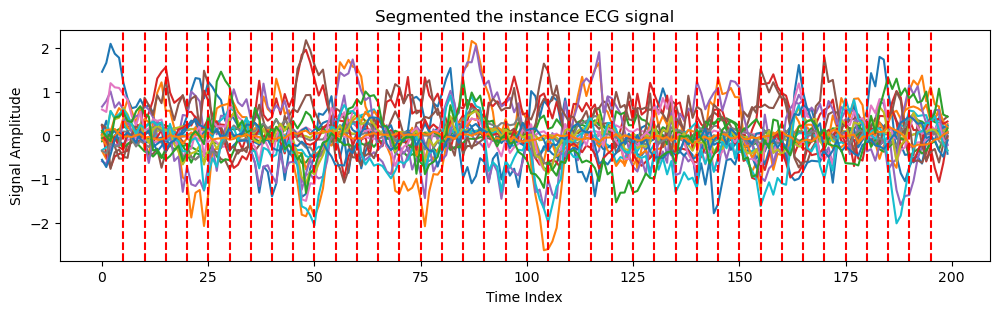

In [11]:
# from lime_explanation import segment_ecg_signal, generate_random_perturbations
# from visualization import plot_segmented_ecg

seq = np.array(inputs[0])

# Segmentation using the fixed number of slices
num_slices = 40 
slice_width = segment_ecg_signal(seq, num_slices)

# plot the segmented ECG signal
plot_segmented_ecg(seq, slice_width)


#### Generate random perturbations

In [12]:
# Perturbation
num_perturbations = 150
random_perturbations = generate_random_perturbations(num_perturbations, num_slices)

# Example output
print("The shape of random_perturbations array (num_perturbations, num_slices):", random_perturbations.shape)
print("Example Perturbation:", random_perturbations[-1])


The shape of random_perturbations array (num_perturbations, num_slices): (150, 40)
Example Perturbation: [0 1 0 1 0 1 1 0 1 1 1 0 1 1 0 1 0 0 1 1 1 0 1 0 0 0 1 1 1 1 0 1 0 0 0 1 1
 1 0 0]


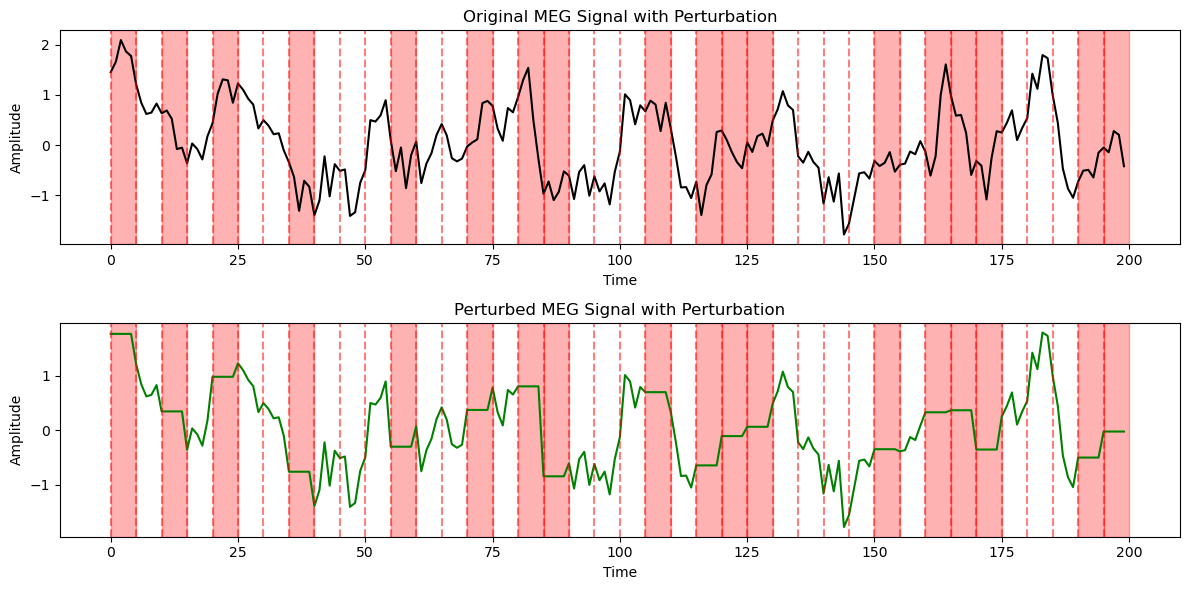

In [16]:
# Apply the Perturbation to the ECG signal and Display
# from lime_explanation import apply_perturbation_to_ecg, perturb_mean
# from visualization import plot_perturbed_ecg

# Choose the perturbation function
perturb_function = perturb_mean  

# Apply a random perturbation to the ECG signal
perturbed_ecg_example = apply_perturbation_to_ecg(seq, random_perturbations[-1], num_slices, perturb_function)

# plot the original and perturbed ECG signals with highlighted slices and deactivated segments
plot_perturbed_ecg(seq[0], perturbed_ecg_example[0], random_perturbations[-1], num_slices, title='MEG Signal with Perturbation')


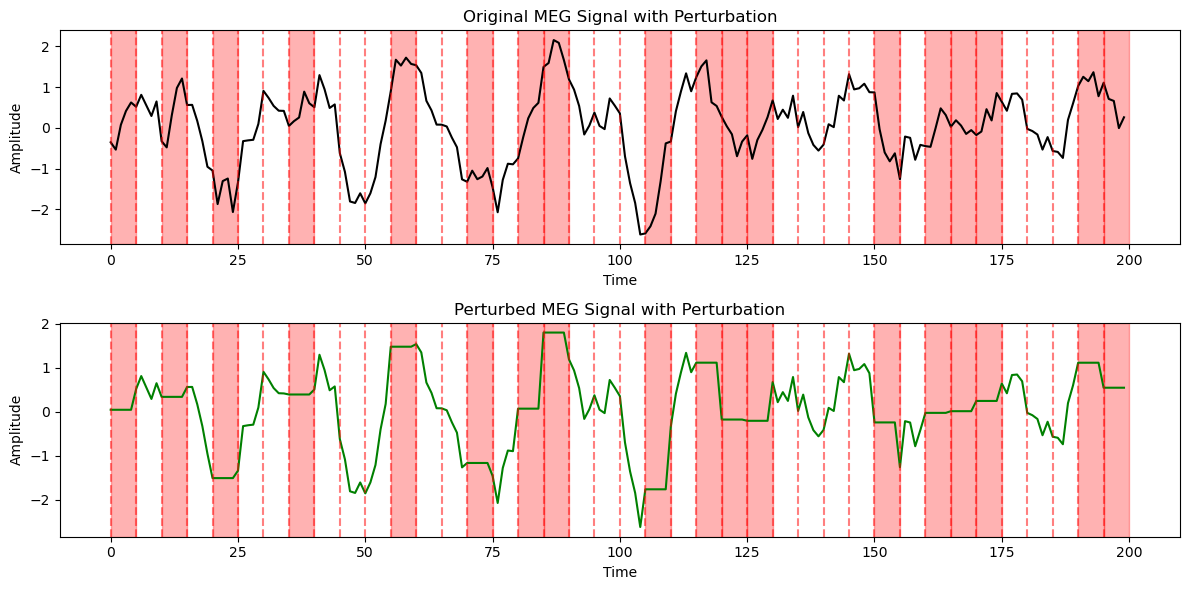

In [17]:
# plot the original and perturbed ECG signals with highlighted slices and deactivated segments
plot_perturbed_ecg(seq[1], perturbed_ecg_example[1], random_perturbations[-1], num_slices, title='MEG Signal with Perturbation')

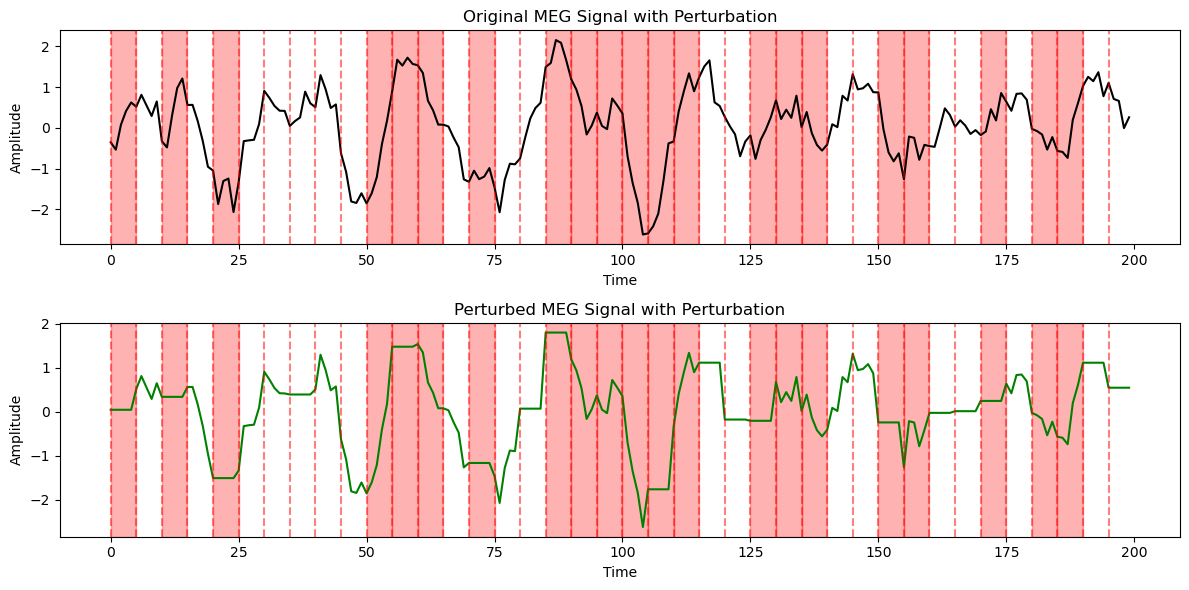

In [45]:
# plot the original and perturbed ECG signals with highlighted slices and deactivated segments
plot_perturbed_ecg(seq[1], perturbed_ecg_example[1], random_perturbations[-2], num_slices, title='MEG Signal with Perturbation')

#### Calculate class probabilities for each perturbed signal

In [46]:
# from lime_explanation import predict_perturbations

## Predict the class probabilities using the trained ECG classifier
perturbation_predictions = predict_perturbations(model, seq, random_perturbations, num_slices, perturb_mean)
print("Shape of perturbation_predictions:", perturbation_predictions.shape)

Shape of perturbation_predictions: (150, 1, 2)


#### Calculate distance from perturbed signal to original signal, and use as weights for interpretable model

In [23]:
# from lime_explanation import calculate_cosine_distances

# Calculate cosine distances between each perturbation and the original ECG signal representation
cosine_distances = calculate_cosine_distances(random_perturbations, num_slices)
print("Shape of Cosine Distances Array:", cosine_distances.shape)

Shape of Cosine Distances Array: (150,)


In [ ]:
# from lime_explanation import calculate_weights_from_distances

#Applying a Kernel Function to Compute Weights
kernel_width = 0.25  # This can be adjusted based on your specific needs
weights = calculate_weights_from_distances(cosine_distances, kernel_width)

# Now we have the weights for each perturbation for further analysis
print("Shape of Weights Array:", weights.shape)

Shape of Weights Array: (150,)
Shape of perturbation_predictions: (150, 1, 2)


#### Train an interpretable model (linear regression) to predict class probabilities from perturbed signal
- segment-wise coefficients represent importance to the model's prediction

In [25]:
# from lime_explanation import fit_explainable_model

# Constructing the Explainable Model for ECG Signals
segment_importance_coefficients = fit_explainable_model(perturbation_predictions, random_perturbations, weights, target_class=1)

# The importance coefficients for each segment
print("Segment Importance Coefficients:", segment_importance_coefficients)


Segment Importance Coefficients: [ 0.00168639  0.00684647 -0.00396966 -0.00069787 -0.00010869 -0.01099883
 -0.01486927  0.00309559 -0.01031014 -0.00606706  0.00647752 -0.00582834
  0.00252394  0.00437589  0.00708672  0.00023893 -0.00398871 -0.00051955
  0.00966976 -0.01235102  0.0060725   0.01195039 -0.00187079  0.00417303
 -0.00042161  0.01316486  0.00256516 -0.00406313  0.00694872  0.02163567
 -0.0185523  -0.00888177  0.00505674 -0.00483149  0.00015591  0.00213798
  0.00314468 -0.00425684  0.00695943 -0.00016351]


#### Identify most important segments and visualize

In [26]:
# Isolating Influential Signal Segments
# from lime_explanation import identify_top_influential_segments

number_of_top_features = 5
top_influential_segments = identify_top_influential_segments(segment_importance_coefficients, number_of_top_features)

# The indices of the top influential segments
print("Top Influential Signal Segments:", top_influential_segments)

Top Influential Signal Segments: [19 25  6 30 29]


/opt/miniconda3/envs/pytorch_env/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/miniconda3/envs/pytorch_env/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


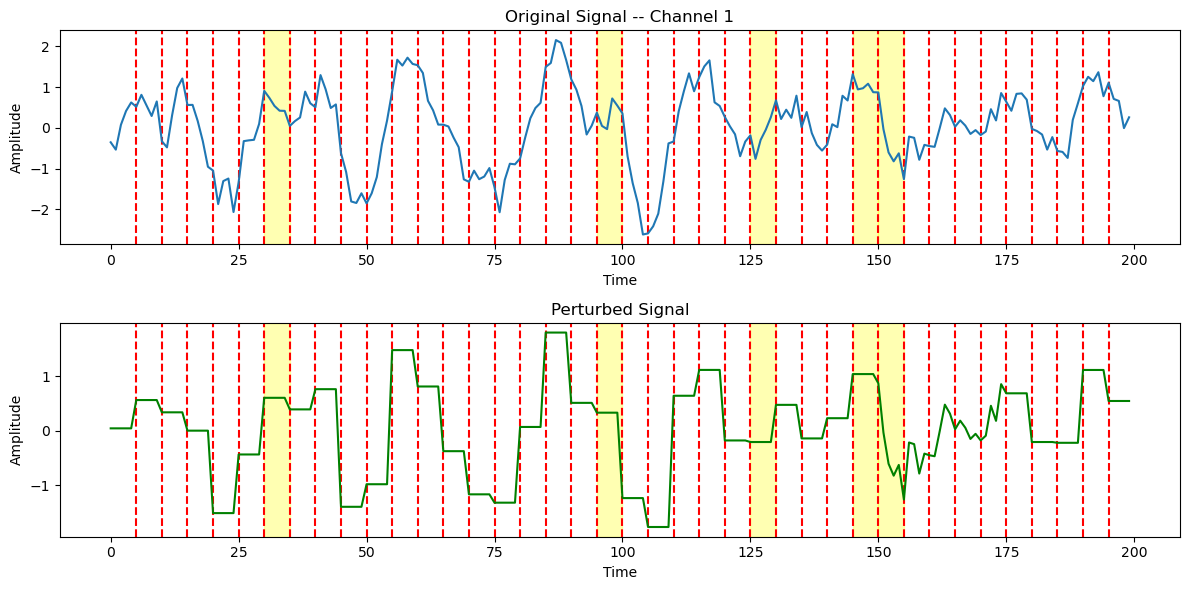

In [48]:
visualize_lime_explanation(seq, top_influential_segments, num_slices, perturb_function=perturb_mean, channel=1)

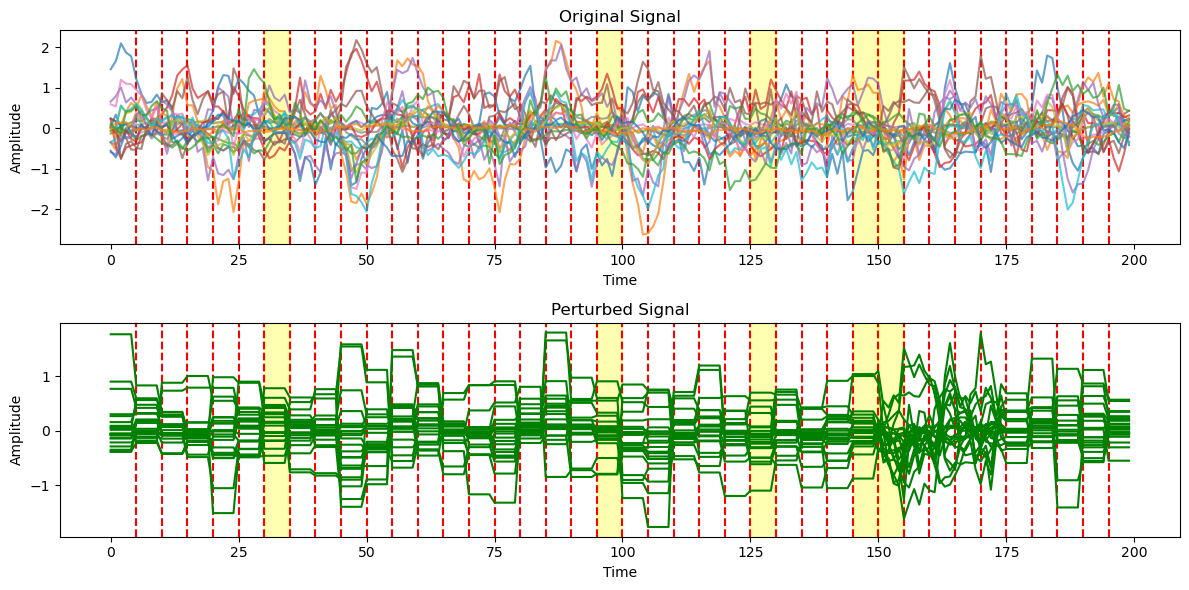

In [49]:
visualize_lime_explanation_all_channels(seq, top_influential_segments, num_slices, perturb_function=perturb_mean)

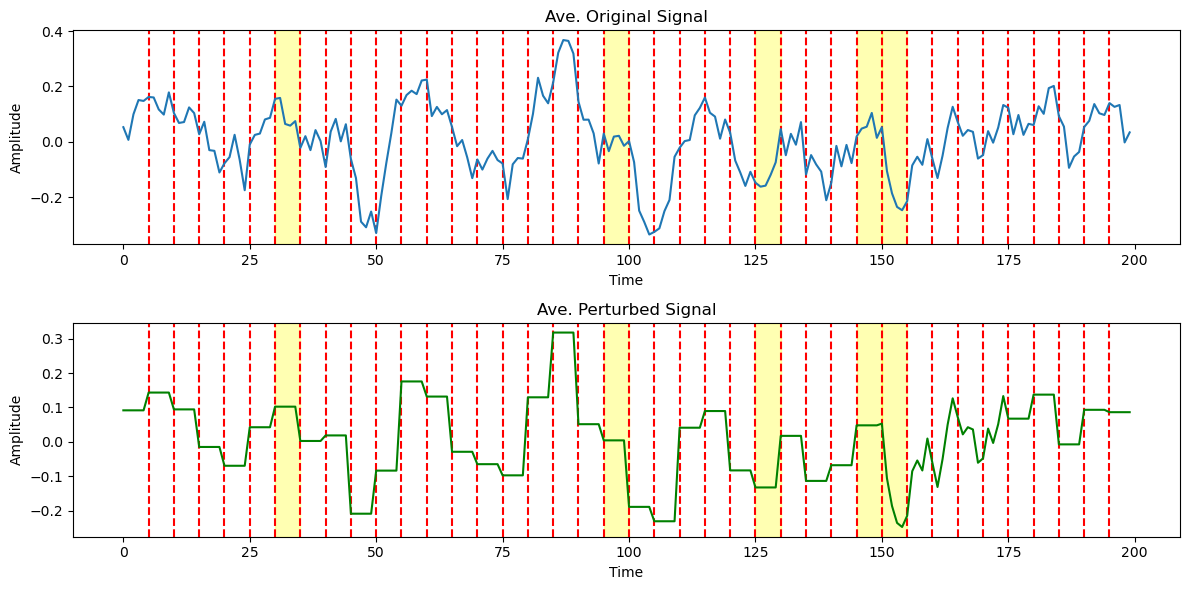

In [50]:
visualize_ave_lime_explanation(seq, top_influential_segments, num_slices, perturb_function=perturb_mean)